# Quantum Simulation of the 1D Ising Model

## Goal of the exercise

This notebook builds and simulates a digital quantum circuit for the real-time dynamics of a one-dimensional Ising chain. The evolution operator is approximated with a product-formula (Trotter–Suzuki) decomposition, and local observables are extracted from the simulated statevector.

The model used below is

$$
H = H_Z + H_{XX}
  = -h\sum_{i=0}^{N-1} Z_i
    -J\sum_{\langle i,j\rangle}X_iX_j,
$$

where $h$ is the field strength, $J$ is the nearest-neighbor coupling, and $\langle i,j\rangle$ denotes the edges of the 1D interaction graph.

### What you will learn

1. How edge coloring groups two-qubit interactions into hardware-parallel layers.
2. How Hamiltonian terms map to Qiskit rotation gates.
3. How a symmetric second-order product formula approximates $e^{-iHt}$.
4. How to obtain $\langle Z_i\rangle$ and connected correlations from a statevector.
5. How to interpret the resulting time-dependent curves and recognize numerical or indexing pitfalls.

### Suggested study path

First identify the Hamiltonian terms and their gate conventions. Then inspect one Trotter step before studying the full time loop. Finally, trace carefully how a statevector basis index is converted into per-qubit spin values; this convention is essential when observables are site resolved.


## Part 1 — Edge Coloring for Parallel Gate Scheduling

The interaction graph has one vertex per qubit and one edge per two-qubit coupling. An edge coloring assigns a label (a “color”) to every edge so that edges with the same color do not share a vertex. Consequently, all gates in one color class can in principle be scheduled in the same circuit layer, provided the target hardware supports those couplings simultaneously.

For an open 1D chain, alternating bonds form two natural groups: $(0,1),(2,3),\ldots$ and $(1,2),(3,4),\ldots$. The generic routine below finds color labels algorithmically. Edge coloring is a scheduling device here; it does not change the Hamiltonian.

> **Study prompt:** For the three-spin example, predict the number of colors and the contents of each color group before running the cell.


In [1]:
# Numerical arrays are used for time grids, probabilities, and observables.
import numpy as np
# Matplotlib provides the time-series visualizations.
import matplotlib.pyplot as plt
# QuantumCircuit stores state preparation and product-formula gates.
from qiskit import QuantumCircuit
# Aer supplies the exact statevector simulation backend used below.
from qiskit_aer import AerSimulator

In [10]:
def colorEdge(edges, e):
    """Color edges such that no two edges sharing a vertex have the same color.
    Args:
        edges: List of [vertex1, vertex2, color] for each edge
        e: Number of edges
    Returns:
        edges: Colored edge list
    Comment:
        coloring exposes potential parallelism in execution of 2-qubit gates, but does not itself guarantee a hardware schedule
        transpilation and backend constraints still matter
    """
    assert(e>0)
    # Add a third mutable field that will hold the color; -1 means unassigned.
    edge_list = [[q, r, -1] for (q, r) in edges]
    # Process one edge at a time and search for a nonconflicting integer color.
    i = 0
    color = 1
    while(i < e):
        edge_list[i][2] = color
        flag = False
        # Compare the candidate edge with every other edge for a shared endpoint.
        for j in range(e):
            if (j == i):
                continue
            if ((edge_list[i][0] == edge_list[j][0])or
                (edge_list[i][1] == edge_list[j][0]) or
                (edge_list[i][0] == edge_list[j][1]) or
                    (edge_list[i][1] == edge_list[j][1])):
                if (edge_list[i][2] == edge_list[j][2]):
                    # Retry this edge with the next candidate color.
                    color += 1
                    flag = True
                    break
        if (flag == True):
            continue
 
        color = 1
        i += 1
 
    # Scan the assigned labels to report the number of color classes.
    maxColor = -1
    for i in range(e):
        maxColor = max(maxColor, edge_list[i][2])
    print(str(maxColor)+" colors needed for edge coloring")
    for i in range(e):
        print("edge between v("+str(edge_list[i][0])+") and v("+ str(edge_list[i][1])+") has color "+str(edge_list[i][2]))

    return edge_list

## Part 2 — Define the 1D Ising Chain

We use an open chain of $N$ spins with nearest-neighbor edges

$$
E=\{(0,1),(1,2),\ldots,(N-2,N-1)\}.
$$

The parameter $J$ sets the strength of the $XX$ interaction and $h$ sets the strength of the $Z$ field. With $\hbar=1$, time is measured in inverse-energy units. The dimensionless quantities controlling the dynamics are therefore $Jt$ and $ht$.

The small default value $N=3$ makes exact statevector simulation inexpensive and lets us inspect every site separately.


In [11]:
# Define 1D Ising chain parameters
# Keep the example small enough that all 2**n_spins amplitudes are inexpensive.
n_spins = 3  # Number of spins
J = 1.0      # Spin-spin coupling strength
h = 0.5      # Transverse field strength

# Create edges for 1D chain
# Open boundary conditions: there is no edge connecting the last site to site 0.
edges = [(i, i+1) for i in range(n_spins-1)]

print(f"1D Ising Chain with {n_spins} spins")
print(f"Edges: {edges}")
print(f"Coupling J = {J}, Field h = {h}")

1D Ising Chain with 3 spins
Edges: [(0, 1), (1, 2)]
Coupling J = 1.0, Field h = 0.5


In [12]:
# Color the edges for parallel gate execution
n_edges = len(edges)
edge_list = colorEdge(edges, n_edges)

# Group edges by color
# Collect the distinct labels returned by the coloring routine.
color_set = set([edge_list[k][2] for k in range(n_edges)])
# Convert the edge list into color -> list of interacting qubit pairs.
colored_edges = {c: [(q, r) for (q, r, c_qr) in edge_list if c_qr == c] for c in color_set}

print(f"\nEdge coloring groups:")
for c in sorted(color_set):
    print(f"  Color {c}: {colored_edges[c]}")

2 colors needed for edge coloring
edge between v(0) and v(1) has color 1
edge between v(1) and v(2) has color 2

Edge coloring groups:
  Color 1: [(0, 1)]
  Color 2: [(1, 2)]


## Part 3 — Trotter–Suzuki Time-Evolution Circuit

Because $H_Z$ and $H_{XX}$ do not generally commute, the exact propagator

$$U(t)=e^{-i(H_Z+H_{XX})t}$$

is replaced by repeated short-time factors. The circuit below uses the symmetric second-order step

$$
U_2(\Delta t)=e^{-iH_Z\Delta t/2}
e^{-iH_{XX}\Delta t}
e^{-iH_Z\Delta t/2},
$$

and approximates $U(t)$ by $[U_2(\Delta t)]^{n}$ with $t=n\Delta t$. For fixed total time, the global error of this formula scales as $O(\Delta t^2)$ under the usual assumptions.

### Gate-angle convention

Qiskit defines

$$R_Z(\theta)=e^{-i\theta Z/2},\qquad
R_{XX}(\theta)=e^{-i\theta X\otimes X/2}.$$

Thus a half field step for $H_Z=-hZ$ uses $R_Z(-h\Delta t)$, while a full interaction step for $-JX_iX_j$ uses $R_{XX}(-2J\Delta t)$. The two $R_Z$ layers together represent the two half steps, not two full field steps.

Barriers are optional visual separators. They help expose the product-formula structure in a circuit drawing but can restrict later compiler optimizations.



Circuit depth: 8

Circuit for t=0.2 (n_trotter=2):


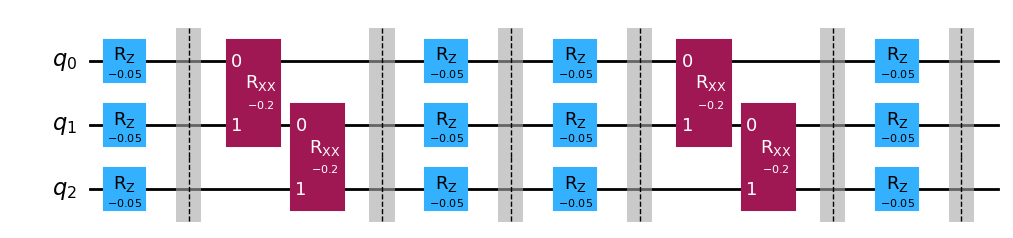

In [13]:
def make_time_evolution_circuit(n_spins, colored_edges, dt, n_trotter, J, h, barrier=False):
    """Create Trotter-Suzuki time evolution circuit.
    
    Args:
        n_spins: Number of qubits
        colored_edges: Dictionary mapping colors to edge lists
        dt: Time step
        n_trotter: Number of Trotter steps
        J: Coupling strength
        h: Field strength
    
    Returns:
        qc: QuantumCircuit object
    """
    # The returned circuit contains evolution only; preparation is composed later.
    qc = QuantumCircuit(n_spins)
    
    # Repeat the symmetric short-time approximation n_trotter times.
    for i_trotter in range(n_trotter):
        # Apply single-qubit Z rotations (field term)
        for q in range(n_spins):
            # RZ(-h*dt) realizes exp(+i*h*dt*Z/2), one field half-step.
            qc.rz(-dt*h, q)
        if(barrier): qc.barrier()
        
        # Apply two-qubit RXX interactions (interaction term) in parallel by color
        for color in sorted(colored_edges.keys()):
            for q, r in colored_edges[color]:
                # RXX(-2*J*dt) realizes exp(+i*J*dt*X⊗X), a full interaction step.
                qc.rxx(-2*J*dt, q, r)
        if(barrier): qc.barrier()
        
        # Symmetry of the half/full/half sequence gives a second-order product formula.
        # Apply single-qubit Z rotations again (second half of Trotter step)
        for q in range(n_spins):
            # RZ(-h*dt) realizes exp(+i*h*dt*Z/2), one field half-step.
            qc.rz(-dt*h, q)
        if(barrier): qc.barrier()
    
    return qc

# Example: Create evolution for t=0.4 with dt=0.1
dt = 0.1
t_total = 0.2
# This conversion assumes t_total is an integer multiple of dt.
n_trotter = int(t_total / dt)

qc_evolution = make_time_evolution_circuit(n_spins, colored_edges, dt, n_trotter, J, h, barrier=True)
print(f"\nCircuit depth: {qc_evolution.depth()}")
print(f"\nCircuit for t={t_total} (n_trotter={n_trotter}):")
#print(qc_evolution)
qc_evolution.draw('mpl')

## Part 4 — Initial-State Preparation

The preparation routine starts from Qiskit’s default computational state $|0\rangle^{\otimes N}$ and optionally applies $X$ gates according to a supplied list of bits. In the convention used later, $|0\rangle$ is the $+1$ eigenstate of $Z$ and $|1\rangle$ is the $-1$ eigenstate.

The chosen product state is simple to prepare and is useful for studying a quench: the system is initialized in an easily characterized state and then evolved under the interacting Hamiltonian.


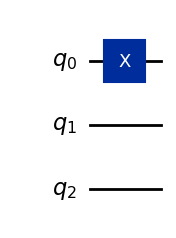

In [22]:
def prepare_initial_state(n_spins, initial_bts=None):
    """Prepare initial quantum state.
    
    Args:
        n_spins: Number of qubits
        initial_bts: Initial bitstring (None for |0⟩^n)
    
    Returns:
        qc: QuantumCircuit object
    """
    # Qiskit initializes every qubit in |0> before any X gates are applied.
    if(initial_bts is not None): assert(len(initial_bts)==n_spins)
    qc = QuantumCircuit(n_spins)
    if initial_bts is not None:
        # Interpret list position i as the Qiskit qubit index to flip.
        for i, xi in enumerate(initial_bts[::-1]):
            if xi == 1:
                # X|0> = |1>, so a 1 in the input selects that basis state.
                qc.x(i)
    return qc

# Prepare initial state (all spins up = all qubits in zero)
# note the ordering with qubit 0 on the right and qubit n-1 on the left
initial_bts=[0,0,1]
qc_init = prepare_initial_state(n_spins, initial_bts=initial_bts)
qc_init.draw('mpl')

## Part 5 — Statevector Simulation and Local Magnetization

The statevector simulator returns the complex amplitudes $\psi_b$ of all computational-basis states $|b\rangle$. Since $Z_i$ is diagonal in this basis,

$$
\langle Z_i\rangle=\sum_b |\psi_b|^2 z_i(b),
$$

where $z_i(b)=+1$ if qubit $i$ is in state $|0\rangle$ and $-1$ if it is in state $|1\rangle$.

This calculation is exact up to floating-point and Trotter errors: it does not introduce finite-shot sampling noise. Its cost is exponential in the number of qubits because a dense statevector contains $2^N$ amplitudes.

In [21]:
def compute_magnetization_statevector(qc, n_spins):
    """Compute local magnetization Z_i using statevector simulation.
    
    Args:
        qc: QuantumCircuit object
        n_spins: Number of qubits
    
    Returns:
        Z_expectation: Array of <Z_i> for each qubit
    """
    # Add statevector save instruction
    # Copy the circuit so the save instruction does not modify the caller's object.
    qc_copy = qc.copy()
    qc_copy.save_statevector()
    
    # Run on statevector simulator
    # No measurement gates or finite-shot sampling are required.
    simulator = AerSimulator(method='statevector')
    result = simulator.run(qc_copy).result()
    psi = result.get_statevector(0)
    
    # Compute <Z_i> for each qubit
    Z_expectation = np.zeros(n_spins, dtype=float)
    
    # Sum diagonal-observable contributions over all computational basis states.
    for state_idx in range(len(psi)):
        # Born probability of the current computational-basis state.
        prob = np.abs(psi[state_idx])**2
        # IMPORTANT: order is qubit 0 on the right
        bitstring = format(state_idx, f'0{n_spins}b')[::-1]
        
        # Convert bitstring to spin values (+1 for 0, -1 for 1)
        # Map a bit b to the corresponding Z eigenvalue: b=0 -> +1, b=1 -> -1.
        spins = np.array([1 - 2*int(b) for b in bitstring])
        
        # Accumulate expectation value
        Z_expectation += prob * spins
    
    return Z_expectation

# Test on initial state
Z_init = compute_magnetization_statevector(qc_init, n_spins)
print(f"Initial magnetization: {Z_init}")
print(f"Total magnetization: {np.sum(Z_init):.4f}")

Initial magnetization: [-1.  1.  1.]
Total magnetization: 1.0000


/var/folders/ms/gmq35hz553d4d73tnzj2xrbw0000gn/T/ipykernel_1744/1898342770.py:26: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for state_idx in range(len(psi)):


## Part 6 — Time-Dependent Magnetization

For every requested time, the notebook rebuilds the initial-state circuit and composes it with a Trotterized evolution circuit. It then records the site-resolved values $\langle Z_i(t)\rangle$.

Rebuilding the circuit makes each time point independent and easy to understand. For larger studies, one could reduce overhead by reusing prefixes, saving intermediate states, or evolving the state numerically between adjacent time points.

To interpret the plot correctly, distinguish three time quantities:

- the requested plotting time $t$;
- the fixed Trotter step $\Delta t$;
- the implemented circuit time $n_{\mathrm{Trotter}}\Delta t$.

These coincide only when $t/\Delta t$ is an integer and the conversion to an integer is handled consistently.


In [28]:
# Simulate dynamics and measure local magnetization vs time
num_steps = 60
dt_step = 0.1
time_points = [x*dt_step for x in range(num_steps+1)]

# Store results for each qubit
# One list per site preserves the site-resolved observable history.
magnetization_data = {i: [] for i in range(n_spins)}
time_data = []

print("Computing time evolution...")
for n_trotter_steps, t in enumerate(time_points):
#for i in num_steps:
#for t in time_points:
#    # Convert the requested time to a whole number of circuit repetitions.
#    n_trotter_steps, = int(t / dt_step)
    
    # Build full circuit: initial state + evolution
    qc_init = prepare_initial_state(n_spins, [0,0,1])
    qc_evol = make_time_evolution_circuit(n_spins, colored_edges, dt_step, n_trotter_steps, J, h)
    # Composition applies preparation first, followed by the evolution gates.
    qc_full = qc_init.compose(qc_evol)
    
    # Measure magnetization
    # Evaluate all local Z expectations from the exact final statevector.
    Z_t = compute_magnetization_statevector(qc_full, n_spins)
    
    # Store results
    for i in range(n_spins):
        magnetization_data[i].append(Z_t[i])
    time_data.append(t)
    
    if int(t*10) % 5 == 0:
        print(f"  t = {t:.2f}: Z_0 = {Z_t[0]:.4f}, Z_mid = {Z_t[n_spins//2]:.4f}")

print("Done!")

Computing time evolution...
  t = 0.00: Z_0 = -1.0000, Z_mid = 1.0000
  t = 0.50: Z_0 = -0.5426, Z_mid = 0.3162
  t = 1.00: Z_0 = 0.3238, Z_mid = 0.1641
  t = 1.50: Z_0 = 0.5571, Z_mid = 0.3860
  t = 2.00: Z_0 = 0.1621, Z_mid = 0.1260
  t = 2.50: Z_0 = 0.0758, Z_mid = 0.8027
  t = 3.00: Z_0 = 0.2348, Z_mid = 0.6546
  t = 3.50: Z_0 = 0.0770, Z_mid = 0.0222
  t = 4.00: Z_0 = -0.3018, Z_mid = 0.4688
  t = 4.50: Z_0 = -0.3485, Z_mid = 0.2745
  t = 5.00: Z_0 = 0.3135, Z_mid = 0.4070
  t = 5.50: Z_0 = 0.9237, Z_mid = 0.8040
  t = 6.00: Z_0 = 0.6031, Z_mid = 0.0996
Done!


/var/folders/ms/gmq35hz553d4d73tnzj2xrbw0000gn/T/ipykernel_1744/1898342770.py:26: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for state_idx in range(len(psi)):


## Part 7 — Visualize the Magnetization

The left panel shows every local observable $\langle Z_i(t)\rangle$. The right panel emphasizes the two edges and the center of the chain, which is helpful for spotting reflection symmetry and boundary effects.

Values must remain in $[-1,1]$ because the eigenvalues of every Pauli-$Z$ operator are $\pm1$. For a reflection-symmetric Hamiltonian and reflection-symmetric initial state, sites $i$ and $N-1-i$ should follow the same curve; deviations can indicate an indexing, circuit-construction, or numerical issue.

The curves include product-formula error but no shot noise. A convergence study would repeat the calculation with smaller $\Delta t$ and compare observables at the same physical times.


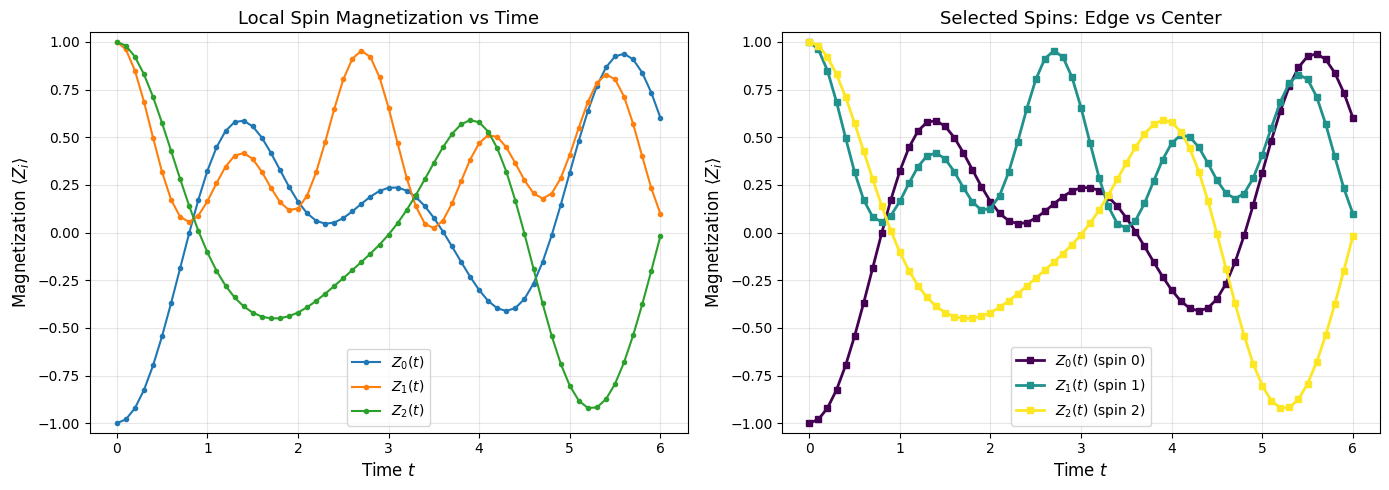


System parameters:
  Number of spins: 3
  Coupling J: 1.0
  Field h: 0.5
  Trotter step: 0.1
  Total evolution time: 6.00


In [30]:
# Plot local magnetization evolution
# Side-by-side panels give both a complete and a symmetry-focused view.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: All spins
ax = axes[0]
# Each line represents one site-resolved expectation value.
for i in range(n_spins):
    ax.plot(time_data, magnetization_data[i], marker='o', markersize=3, label=f'$Z_{{{i}}}(t)$')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('Magnetization $\\langle Z_i \\rangle$', fontsize=12)
ax.set_title('Local Spin Magnetization vs Time', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
# Pauli-Z expectations lie in [-1, 1]; the margin prevents visual clipping.
ax.set_ylim([-1.05, 1.05])

# Plot 2: Selected spins for clarity
ax = axes[1]
# Compare both boundaries with the chain center.
selected_spins = [0, n_spins//2, n_spins-1]
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_spins)))
for idx, i in enumerate(selected_spins):
    ax.plot(time_data, magnetization_data[i], marker='s', markersize=4, 
            label=f'$Z_{{{i}}}(t)$ (spin {i})', linewidth=2, color=colors[idx])
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('Magnetization $\\langle Z_i \\rangle$', fontsize=12)
ax.set_title('Selected Spins: Edge vs Center', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10)
# Pauli-Z expectations lie in [-1, 1]; the margin prevents visual clipping.
ax.set_ylim([-1.05, 1.05])

plt.tight_layout()
plt.show()

print(f"\nSystem parameters:")
print(f"  Number of spins: {n_spins}")
print(f"  Coupling J: {J}")
print(f"  Field h: {h}")
print(f"  Trotter step: {dt_step}")
print(f"  Total evolution time: {max(time_data):.2f}")

## Part 8 — Connected Spin Correlations

The connected $ZZ$ correlation between sites $i$ and $j$ is

$$
C_{ij}^{ZZ}(t)=\langle Z_iZ_j\rangle
-\langle Z_i\rangle\langle Z_j\rangle.
$$

Subtracting the product of one-site averages removes the disconnected contribution. For a product state, all connected correlations initially vanish. Interactions can generate nonzero correlations as information spreads through the chain.

The statevector loop computes both the one-site averages and the full matrix $\langle Z_iZ_j\rangle$. The plotted choice of pairs determines whether the result should be described as nearest-neighbor correlations or as all pairwise correlations.


/var/folders/ms/gmq35hz553d4d73tnzj2xrbw0000gn/T/ipykernel_1744/1942480177.py:22: DeprecationWarning: The return type of saved statevectors has been changed from a `numpy.ndarray` to a `qiskit.quantum_info.Statevector` as of qiskit-aer 0.10. Accessing numpy array attributes is deprecated and will result in an error in a future release. To continue using saved result objects as arrays you can explicitly cast them using  `np.asarray(object)`.
  for state_idx in range(len(psi)):


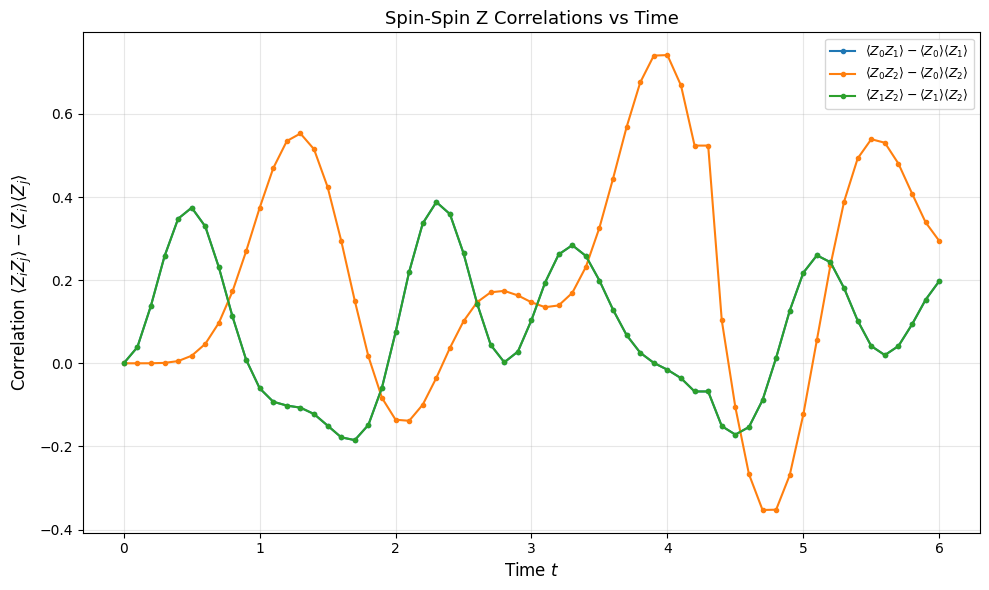

In [33]:
def compute_nn_correlations_statevector(qc, n_spins):
    """Compute nearest-neighbor spin correlations.
    
    Returns:
        correlations: Array of <Z_i Z_{i+1}> for each pair
    """
    # Add statevector save instruction
    qc_copy = qc.copy()
    qc_copy.save_statevector()
    
    # Run on statevector simulator
    simulator = AerSimulator(method='statevector')
    result = simulator.run(qc_copy).result()
    psi = result.get_statevector(0)
    
    # Compute <Z_i Z_j> for each pair
    # Store raw two-site moments <Z_i Z_j> before subtracting the product of means.
    correlations = np.zeros((n_spins, n_spins), dtype=float)
    # Accumulate the one-site means needed for the connected correlator.
    averages = np.zeros(n_spins, dtype=float)
    
    for state_idx in range(len(psi)):
        prob = np.abs(psi[state_idx])**2
        # IMPORTANT: the MSB-first ordering issue also affects site labels here.
        bitstring = format(state_idx, f'0{n_spins}b')
        spins = np.array([1 - 2*int(b) for b in bitstring])
        
        # Accumulate pairwise correlations
        for i in range(n_spins):
            averages[i] += prob * spins[i]
            for j in range(n_spins):
                # Z_i Z_j is diagonal, so its eigenvalue is the product of the two spins.
                correlations[i,j] += prob * spins[i] * spins[j]
    
    # Outer product subtraction gives C_ij = <Z_i Z_j> - <Z_i><Z_j>.
    return correlations - np.einsum('i,j->ij', averages, averages)

# Compute correlations at different times
# The current comprehension includes every distinct pair, not only adjacent sites.
correlation_data = {(i,j): [] for i in range(n_spins) for j in range(n_spins) if i<j}

for t in time_points:
    n_trotter_steps = int(t / dt_step)
    qc_init = prepare_initial_state(n_spins)
    qc_evol = make_time_evolution_circuit(n_spins, colored_edges, dt_step, n_trotter_steps, J, h)
    qc_full = qc_init.compose(qc_evol)
    
    corr = compute_nn_correlations_statevector(qc_full, n_spins)
    for i in range(n_spins):
        for j in range(i+1,n_spins):
            correlation_data[(i,j)].append(corr[i,j])

# Plot correlations
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_spins):
    for j in range(i+1,n_spins):
        ax.plot(time_data, correlation_data[(i,j)], marker='o', markersize=3, 
                label=f'$\\langle Z_{{{i}}}Z_{{{j}}} \\rangle - \\langle Z_{{{i}}} \\rangle \\langle Z_{{{j}}} \\rangle$')
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('Correlation $\\langle Z_i Z_{j} \\rangle - \\langle Z_i \\rangle \\langle Z_j \\rangle $', fontsize=12)
ax.set_title('Spin-Spin Z Correlations vs Time', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## Summary

This notebook connects four layers of a digital quantum-simulation workflow:

1. **Interaction graph:** nearest-neighbor couplings are represented as graph edges and grouped into parallelizable color classes.
2. **Hamiltonian-to-gate mapping:** the factors of two and the signs of the rotation angles follow from Qiskit’s definitions of $R_Z$ and $R_{XX}$.
3. **Product-formula dynamics:** a symmetric second-order Trotter step alternates a half field layer, a full interaction layer, and another half field layer.
4. **Observable extraction:** probabilities from the exact statevector are weighted by Pauli eigenvalues to obtain magnetizations and connected correlations.

The field and interaction compete to produce nontrivial dynamics. Exact statevector simulation is valuable for small-system validation, while its exponential memory cost prevents direct scaling to large chains.
